In [1]:
import subprocess , sys 
package = ["pyflakes", "scikit-learn", "radon", "pandas", "numpy", "matplotlib", "seaborn"]
subprocess.check_call([sys.executable, "-m", "pip", "install"] + package)
print("All packages have been installed successfully.")

All packages have been installed successfully.


In [2]:
import ast
import io
import os
import re
import json
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib  import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


In [3]:
#path configuration
labeled_csv = Path("C:\\Users\\LOQ\\Documents\\code_quality_machine\\output\\labeled_dataset.csv")
output_DIR = Path("C:\\Users\\LOQ\\Documents\\code_quality_machine\\output")
os.makedirs(output_DIR, exist_ok=True)

feature_csv = output_DIR / "features_dataset.csv"
x_train_csv = output_DIR / "x_train.csv"
x_test_csv = output_DIR / "x_test.csv"
y_train_csv = output_DIR / "y_train.csv"
y_test_csv = output_DIR / "y_test.csv"
scaler_path = output_DIR / "scaler.json"
encoder_path = output_DIR / "encoder.json"
tfidf_vocab = output_DIR / "tfidf_vocab.json"
test_size = 0.2
random_state = 42
tfidf_features = 200 
print(f"Paths have been configured successfully to {output_DIR}.")


Paths have been configured successfully to C:\Users\LOQ\Documents\code_quality_machine\output.


In [4]:
df = pd.read_csv(labeled_csv)
print(f"Dataset loaded successfully with shape: {df.shape}")
df.head()


Dataset loaded successfully with shape: (1006, 16)


,repo,repo_url,stars,file_path,file_size,mi_score,avg_cc,max_cc,loc,lloc,sloc,comments,blank,comment_ratio,quality_label,code
0,public-apis/public-apis,https://github.com/public-apis/public-apis,424462,scripts/tests/test_validate_format.py,18154,35.41,1.72,4,466,253,362,3,103,0.012,bad,# -*- coding: utf-8 -*-\n\nimport unittest\n\n...
1,public-apis/public-apis,https://github.com/public-apis/public-apis,424462,scripts/tests/test_validate_links.py,5725,100.00,1.36,2,172,82,132,1,39,0.012,good,# -*- coding: utf-8 -*-\n\nimport unittest\n\n...
2,public-apis/public-apis,https://github.com/public-apis/public-apis,424462,scripts/validate/format.py,8464,39.64,4.18,14,277,175,183,9,85,0.051,bad,# -*- coding: utf-8 -*-\n\nimport re\nimport s...
3,public-apis/public-apis,https://github.com/public-apis/public-apis,424462,scripts/validate/links.py,8032,52.87,3.64,8,273,136,158,2,85,0.015,medium,# -*- coding: utf-8 -*-\n\nimport re\nimport s...
4,EbookFoundation/free-programming-books,https://github.com/EbookFoundation/free-progra...,385637,scripts/rtl_ltr_linter.py,27037,40.34,17.33,57,605,206,255,142,129,0.689,bad,"#!/usr/bin/env python3\n""""""\nRTL/LTR Markdown ..."


In [5]:
# Check column types and missing values
print("── Column overview ──────────────────────────────")
info = pd.DataFrame({
    "dtype":   df.dtypes,
    "non_null": df.notnull().sum(),
    "missing":  df.isnull().sum(),
    "missing%": (df.isnull().mean() * 100).round(1)
})
print(info.to_string())

── Column overview ──────────────────────────────
                 dtype  non_null  missing  missing%
repo            object      1006        0       0.0
repo_url        object      1006        0       0.0
stars            int64      1006        0       0.0
file_path       object      1006        0       0.0
file_size        int64      1006        0       0.0
mi_score       float64      1006        0       0.0
avg_cc         float64      1006        0       0.0
max_cc           int64      1006        0       0.0
loc              int64      1006        0       0.0
lloc             int64      1006        0       0.0
sloc             int64      1006        0       0.0
comments         int64      1006        0       0.0
blank            int64      1006        0       0.0
comment_ratio  float64      1006        0       0.0
quality_label   object      1006        0       0.0
code            object      1006        0       0.0


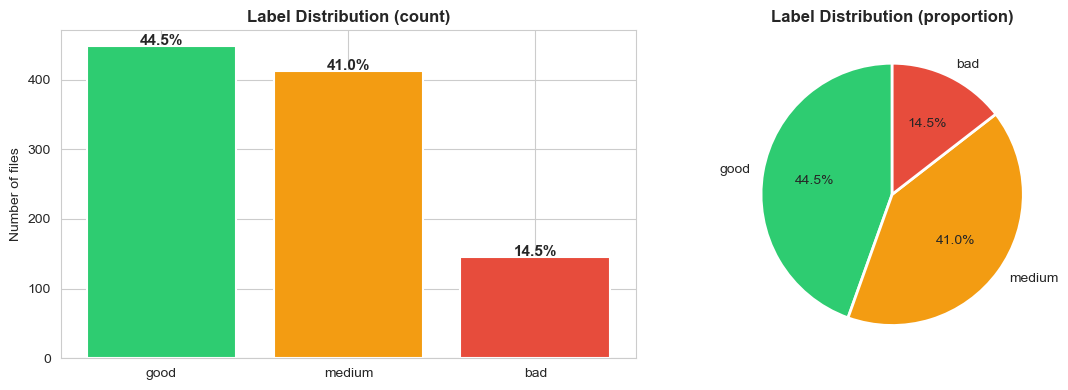


── Label counts ──
  good    :  448 files
  medium  :  412 files
  bad     :  146 files


In [6]:
#Label distribution  we need balanced classes for a fair model
label_counts = df["quality_label"].value_counts()
label_pcts   = df["quality_label"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = {"good": "#2ecc71", "medium": "#f39c12", "bad": "#e74c3c"}
bar_colors = [colors.get(l, "#95a5a6") for l in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Label Distribution (count)", fontweight="bold")
axes[0].set_ylabel("Number of files")
for i, (v, p) in enumerate(zip(label_counts.values, label_pcts.values)):
    axes[0].text(i, v + 1, f"{p:.1f}%", ha="center", fontsize=11, fontweight="bold")
# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=bar_colors, autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Label Distribution (proportion)", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{output_DIR}/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Label counts ──")
for label, count in label_counts.items():
    print(f"  {label:<8}: {count:>4} files")

In [7]:
before = len(df)
df = df.dropna(subset=["code", "quality_label"])
print(f"Rows kept: {len(df)} / {before}  (dropped {before - len(df)} with missing code or label)")
df = df.reset_index(drop=True)

Rows kept: 1006 / 1006  (dropped 0 with missing code or label)


## Step 2 — AST Structural Features

Parse each file's **Abstract Syntax Tree** using Python's built-in `ast` module to extract structural information about how the code is organised — things Radon's raw metrics can't capture.

| Feature | What it measures |
|---------|-----------------|
| `ast_functions` | Number of function definitions |
| `ast_classes` | Number of class definitions |
| `ast_imports` | Number of import statements |
| `ast_max_depth` | Maximum nesting depth of the AST |
| `ast_avg_args` | Average number of arguments per function |
| `ast_lambdas` | Number of lambda expressions |
| `ast_comprehensions` | Number of list/dict/set comprehensions |
| `ast_try_blocks` | Number of try/except blocks |
| `ast_returns` | Number of return statements |
| `ast_global_vars` | Number of global variable assignments at module level |
| `ast_docstring_ratio` | Fraction of functions that have a docstring |
| `ast_assert_count` | Number of assert statements (signals test awareness) |
| `ast_parse_error` | 1 if AST parsing failed, 0 if OK |


In [8]:
def get_tree_depth(node , depth=0):
    #recursively calculate the depth of the AST tree
    if not isinstance(node, ast.AST):
        return depth
    children = list(ast.iter_child_nodes(node))
    if not children:
        return depth
    return max(get_tree_depth(child, depth + 1) for child in children)
def extract_ast_features(code: str) -> dict:
    #parse the code into an AST and extract features like depth,
    # number of functions, classes, and imports
    base = {
         "ast_functions":       0,
        "ast_classes":         0,
        "ast_imports":         0,
        "ast_max_depth":       0,
        "ast_avg_args":        0.0,
        "ast_lambdas":         0,
        "ast_comprehensions":  0,
        "ast_try_blocks":      0,
        "ast_returns":         0,
        "ast_global_vars":     0,
        "ast_docstring_ratio": 0.0,
        "ast_assert_count":    0,
        "ast_parse_error":     0,
    }

    try:
        tree = ast.parse(code)
    except SyntaxError:
        base["ast_parse_error"] = 1
        return base
    functions = [n for n in ast.walk(tree) if isinstance(n, ast.FunctionDef)]
    classes   = [n for n in ast.walk(tree) if isinstance(n, ast.ClassDef)]
    imports   = [n for n in ast.walk(tree) if isinstance(n, (ast.Import, ast.ImportFrom))]
    lambdas   = [n for n in ast.walk(tree) if isinstance(n, ast.Lambda)]
    comps     = [n for n in ast.walk(tree) if isinstance(n, (ast.ListComp, ast.SetComp, ast.DictComp, ast.GeneratorExp))] 
    try_blocks = [n for n in ast.walk(tree) if isinstance(n, ast.Try)]
    returns    = [n for n in ast.walk(tree) if isinstance(n, ast.Return)]
    asserts    = [n for n in ast.walk(tree) if isinstance(n, ast.Assert)]
    global_vars = [n for n in ast.walk(tree) if isinstance(n, (ast.Assign, ast.AnnAssign, ast.AugAssign))]
    arg_counts = [len(fn.args.args) for fn in functions]
    avg_args   = np.mean(arg_counts) if arg_counts else 0.0
    def has_docstring(fn):
        return (
            fn.body and
            isinstance(fn.body[0], ast.Expr) and
            isinstance(fn.body[0].value, ast.Constant) and
            isinstance(fn.body[0].value.value, str)
        )
    doc_ratio = (
        sum(1 for fn in functions if has_docstring(fn)) / len(functions)
        if functions else 0.0
    )
    return {
        "ast_functions":       len(functions),
        "ast_classes":         len(classes),
        "ast_imports":         len(imports),
        "ast_max_depth":       get_tree_depth(tree),
        "ast_avg_args":        avg_args,
        "ast_lambdas":         len(lambdas),
        "ast_comprehensions":  len(comps),
        "ast_try_blocks":      len(try_blocks),
        "ast_returns":         len(returns),
        "ast_global_vars":     len(global_vars),
        "ast_docstring_ratio": doc_ratio,
        "ast_assert_count":    len(asserts),
        "ast_parse_error":     0,
    }


In [9]:
# Quick smoke test
sample = '''
import os

def greet(name: str) -> str:
    """Return a greeting string."""
    if not name:
        raise ValueError("name required")
    return f"Hello, {name}"

class Greeter:
    def __init__(self, prefix="Hi"):
        self.prefix = prefix

    def greet(self, name):
        return f"{self.prefix}, {name}"
'''

print(json.dumps(extract_ast_features(sample), indent=2))

{
  "ast_functions": 3,
  "ast_classes": 1,
  "ast_imports": 1,
  "ast_max_depth": 8,
  "ast_avg_args": 1.6666666666666667,
  "ast_lambdas": 0,
  "ast_comprehensions": 0,
  "ast_try_blocks": 0,
  "ast_returns": 2,
  "ast_global_vars": 1,
  "ast_docstring_ratio": 0.3333333333333333,
  "ast_assert_count": 0,
  "ast_parse_error": 0
}


In [12]:
# Apply AST feature extraction to the full dataset
print(f"Extracting AST features from {len(df)} files...")

ast_rows = [extract_ast_features(code) for code in df["code"]]
ast_df   = pd.DataFrame(ast_rows, index=df.index)

parse_errors = ast_df["ast_parse_error"].sum()
print(f"  Parse errors  : {parse_errors} / {len(df)}  ({100*parse_errors/len(df):.1f}%)")
print(f"  AST features  : {ast_df.shape[1]} columns")
print("\nSample AST feature stats:")
print(ast_df.describe().round(2).to_string())

Extracting AST features from 1006 files...
  Parse errors  : 0 / 1006  (0.0%)
  AST features  : 13 columns

Sample AST feature stats:
       ast_functions  ast_classes  ast_imports  ast_max_depth  ast_avg_args  ast_lambdas  ast_comprehensions  ast_try_blocks  ast_returns  ast_global_vars  ast_docstring_ratio  ast_assert_count  ast_parse_error
count        1006.00      1006.00      1006.00        1006.00       1006.00      1006.00             1006.00         1006.00      1006.00          1006.00              1006.00           1006.00           1006.0
mean            8.48         1.54         7.73          10.48          1.51         0.40                1.45            1.08         6.47            32.45                 0.35              1.65              0.0
std            13.35         4.10        11.57           2.95          1.39         3.27                3.24            2.51        11.55            47.78                 0.41              7.39              0.0
min             0.00  

## Step 3 — Lint Signals (pyflakes)

Run `pyflakes` on each file to count the number of **errors** and **warnings** it raises. These are lightweight but highly informative signals — a file with many undefined names or unused imports is almost certainly bad quality.

| Feature | Meaning |
|---------|---------|
| `lint_errors` | Undefined names, import errors |
| `lint_warnings` | Unused imports, redefined vars |
| `lint_total` | Total lint issues |
| `lint_per_loc` | Issues normalised by lines of code |

In [15]:
def extract_lint_features(code: str, loc: int = 1) -> dict:
    """
    Run pyflakes on code string and count issues.
    Returns error/warning counts.
    """
    import pyflakes.api   as pf_api
    import pyflakes.reporter as pf_rep

    error_buf   = io.StringIO()
    warning_buf = io.StringIO()

    class SplitReporter(pf_rep.Reporter):
        """Separate errors vs warnings."""
        def unexpectedError(self, filename, msg):
            error_buf.write(msg + "\n")
        def syntaxError(self, filename, msg, lineno, offset, text):
            error_buf.write(msg + "\n")
        def flake(self, message):
            txt = str(message)
            if any(kw in txt for kw in ("undefined", "import *", "SyntaxError")):
                error_buf.write(txt + "\n")
            else:
                warning_buf.write(txt + "\n")

    try:
        reporter = SplitReporter(warning_buf, error_buf)
        pf_api.check(code, filename="<string>", reporter=reporter)
    except Exception:
        pass

    errors   = len([l for l in error_buf.getvalue().splitlines()   if l.strip()])
    warnings = len([l for l in warning_buf.getvalue().splitlines() if l.strip()])
    total    = errors + warnings
    loc_safe = max(loc, 1)

    return {
        "lint_errors":   errors,
        "lint_warnings": warnings,
        "lint_total":    total,
        "lint_per_loc":  round(total / loc_safe, 4),
    }


# Smoke test
bad_code = '''
import os
import sys  # unused

def broken():
    print(undefined_var)   # undefined name
    x = 1
    x = 2   # redefined
'''
print(extract_lint_features(bad_code, loc=8))

{'lint_errors': 1, 'lint_warnings': 3, 'lint_total': 4, 'lint_per_loc': 0.5}


In [16]:
# Apply to full dataset
print(f"Running pyflakes on {len(df)} files...")

loc_col = df["loc"] if "loc" in df.columns else pd.Series([1]*len(df))
lint_rows = [
    extract_lint_features(code, loc)
    for code, loc in zip(df["code"], loc_col)
]
lint_df = pd.DataFrame(lint_rows, index=df.index)

print("\nLint feature stats:")
print(lint_df.describe().round(3).to_string())

Running pyflakes on 1006 files...

Lint feature stats:
       lint_errors  lint_warnings  lint_total  lint_per_loc
count     1006.000       1006.000    1006.000      1006.000
mean         0.315          0.407       0.722         0.008
std          4.841          1.823       5.178         0.065
min          0.000          0.000       0.000         0.000
25%          0.000          0.000       0.000         0.000
50%          0.000          0.000       0.000         0.000
75%          0.000          0.000       0.000         0.000
max        113.000         30.000     113.000         1.546


Average lint issues per label:
               lint_errors  lint_warnings  lint_total
quality_label                                        
bad                  1.493          0.397       1.890
good                 0.062          0.598       0.661
medium               0.172          0.201       0.374


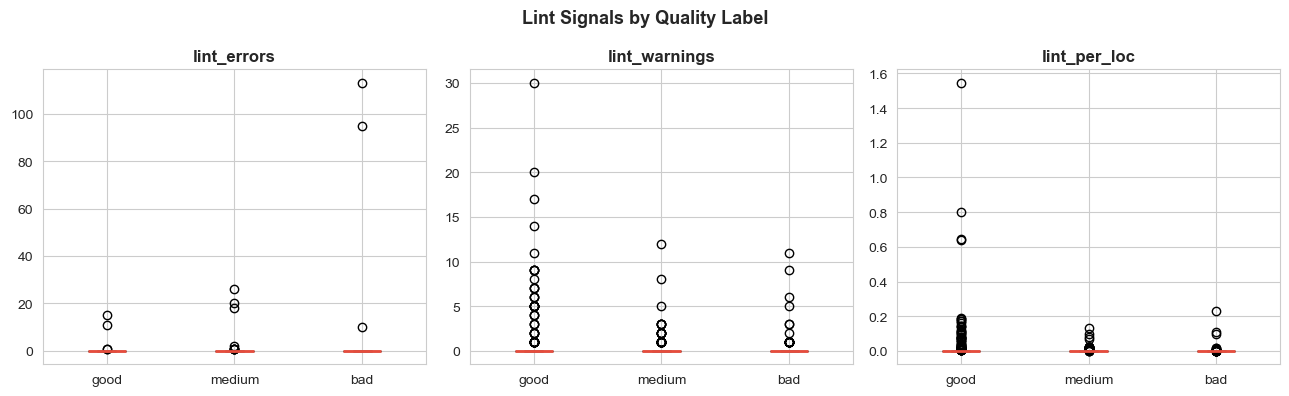

In [17]:
# Average lint issues per label
from config import OUTPUT_DIR


temp = pd.concat([df["quality_label"], lint_df], axis=1)
print("Average lint issues per label:")
print(temp.groupby("quality_label")[["lint_errors","lint_warnings","lint_total"]].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(["lint_errors", "lint_warnings", "lint_per_loc"]):
    data = [temp[temp["quality_label"] == lbl][col].dropna()
            for lbl in ["good", "medium", "bad"]]
    axes[i].boxplot(data, labels=["good", "medium", "bad"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#FDEBD0"),
                    medianprops=dict(color="#E74C3C", linewidth=2))
    axes[i].set_title(col, fontweight="bold")

plt.suptitle("Lint Signals by Quality Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/lint_features_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 4 — TF-IDF Token Vectors

Tokenise each code file and compute **TF-IDF (Term Frequency – Inverse Document Frequency)** scores over code tokens. This captures vocabulary patterns:

- Good code uses descriptive names (`calculate_average`, `user_id`)
- Bad code uses cryptic abbreviations (`x`, `tmp`, `f2`)

We keep the top `TFIDF_FEATURES` (200) most informative tokens to keep the feature matrix manageable.


In [18]:
def tokenize_code(code: str) -> str:
    """
    Clean code for TF-IDF:
    - Remove string literals and comments
    - Split camelCase and snake_case identifiers into sub-tokens
    - Lower-case everything
    """
    # Remove string literals
    code = re.sub(r'""".*?"""', ' ', code, flags=re.DOTALL)
    code = re.sub(r"'''.*?'''",   ' ', code, flags=re.DOTALL)
    code = re.sub(r'"[^"]*"',     ' ', code)
    code = re.sub(r"'[^']*'",     ' ', code)
    # Remove comments
    code = re.sub(r'#.*',         ' ', code)
    # Split snake_case  →  individual words
    code = code.replace('_', ' ')
    # Split camelCase   →  individual words
    code = re.sub(r'([a-z])([A-Z])', r'\1 \2', code)
    # Keep only alphanumeric tokens
    code = re.sub(r'[^a-zA-Z0-9\s]', ' ', code)
    # Collapse whitespace
    code = re.sub(r'\s+', ' ', code).strip().lower()
    return code


# Test tokeniser
sample_code = '''
def calculateUserScore(user_id, rawData):
    """Calculate score from raw data."""
    x = rawData["value"]  # TODO: fix this
    return x * 100
'''
print("Original:")
print(sample_code)
print("\nTokenized:")
print(tokenize_code(sample_code))

Original:

def calculateUserScore(user_id, rawData):
    """Calculate score from raw data."""
    x = rawData["value"]  # TODO: fix this
    return x * 100


Tokenized:
def calculate user score user id raw data x raw data return x 100


In [24]:
# Fit TF-IDF on the full corpus
print(f"Fitting TF-IDF on {len(df)} code files  (max_features={tfidf_features})...")

tokenized_corpus = [tokenize_code(c) for c in df["code"]]

tfidf = TfidfVectorizer(
    max_features   = tfidf_features,
    min_df         = 2,          # token must appear in at least 2 files
    max_df         = 0.95,       # ignore tokens in >95% of files (too common)
    sublinear_tf   = True,       # apply log(1+tf) — dampens very frequent tokens
    ngram_range    = (1, 2),     # unigrams + bigrams
    token_pattern  = r"\b[a-z][a-z0-9]{1,}\b",  # real words only
)

tfidf_matrix = tfidf.fit_transform(tokenized_corpus)
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{t}" for t in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"\nTop 20 vocabulary tokens:")
print(tfidf.get_feature_names_out()[:20])

# Save vocabulary for inference later
with open(tfidf_vocab, "w") as f:
    json.dump({token: int(idx) for token, idx in tfidf.vocabulary_.items()}, f)
print(f"\nVocabulary saved → {tfidf_vocab}")

tokenized_corpus = [tokenize_code(c) for c in df["code"]]

tfidf = TfidfVectorizer(
    max_features   = tfidf_features,
    min_df         = 2,
    max_df         = 0.95,
    sublinear_tf   = True,
    ngram_range    = (1, 2),
    token_pattern  = r"\b[a-z][a-z0-9]{1,}\b",
)

tfidf_matrix = tfidf.fit_transform(tokenized_corpus)
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{t}" for t in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"\nTop 20 vocabulary tokens:")
print(tfidf.get_feature_names_out()[:20])

# Save vocabulary for inference later
# Fit TF-IDF on the full corpus
print(f"Fitting TF-IDF on {len(df)} code files  (max_features={tfidf_features})...")

tokenized_corpus = [tokenize_code(c) for c in df["code"]]

tfidf = TfidfVectorizer(
    max_features   = tfidf_features,
    min_df         = 2,          # token must appear in at least 2 files
    max_df         = 0.95,       # ignore tokens in >95% of files (too common)
    sublinear_tf   = True,       # apply log(1+tf) — dampens very frequent tokens
    ngram_range    = (1, 2),     # unigrams + bigrams
    token_pattern  = r"\b[a-z][a-z0-9]{1,}\b",  # real words only
)

tfidf_matrix = tfidf.fit_transform(tokenized_corpus)
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{t}" for t in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"\nTop 20 vocabulary tokens:")
print(tfidf.get_feature_names_out()[:20])

# Save vocabulary for inference later
with open(tfidf_vocab, "w") as f:
    json.dump({token: int(idx) for token, idx in tfidf.vocabulary_.items()}, f)
print(f"\nVocabulary saved → {tfidf_vocab}")

tokenized_corpus = [tokenize_code(c) for c in df["code"]]

tfidf = TfidfVectorizer(
    max_features   = tfidf_features,
    min_df         = 2,
    max_df         = 0.95,
    sublinear_tf   = True,
    ngram_range    = (1, 2),
    token_pattern  = r"\b[a-z][a-z0-9]{1,}\b",
)

tfidf_matrix = tfidf.fit_transform(tokenized_corpus)
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{t}" for t in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"\nTop 20 vocabulary tokens:")
print(tfidf.get_feature_names_out()[:20])

# Save vocabulary for inference later
with open(tfidf_vocab, "w") as f:
    json.dump({token: int(idx) for token, idx in tfidf.vocabulary_.items()}, f)
print(f"\nVocabulary saved → {tfidf_vocab}")
print(f"\nVocabulary saved → {tfidf_vocab}")

Fitting TF-IDF on 1006 code files  (max_features=200)...
TF-IDF matrix shape: (1006, 200)

Top 20 vocabulary tokens:
['action' 'add' 'add argument' 'all' 'and' 'any' 'api' 'app' 'append'
 'arg' 'args' 'argument' 'as' 'assert' 'async' 'await' 'base' 'batch'
 'block' 'bool']

Vocabulary saved → C:\Users\LOQ\Documents\code_quality_machine\output\tfidf_vocab.json
TF-IDF matrix shape: (1006, 200)

Top 20 vocabulary tokens:
['action' 'add' 'add argument' 'all' 'and' 'any' 'api' 'app' 'append'
 'arg' 'args' 'argument' 'as' 'assert' 'async' 'await' 'base' 'batch'
 'block' 'bool']
Fitting TF-IDF on 1006 code files  (max_features=200)...
TF-IDF matrix shape: (1006, 200)

Top 20 vocabulary tokens:
['action' 'add' 'add argument' 'all' 'and' 'any' 'api' 'app' 'append'
 'arg' 'args' 'argument' 'as' 'assert' 'async' 'await' 'base' 'batch'
 'block' 'bool']

Vocabulary saved → C:\Users\LOQ\Documents\code_quality_machine\output\tfidf_vocab.json
TF-IDF matrix shape: (1006, 200)

Top 20 vocabulary tokens:

In [25]:
# Show top discriminating tokens per label
print("Top TF-IDF tokens by average score per label:\n")
temp = pd.concat([df["quality_label"].reset_index(drop=True),
                  tfidf_df.reset_index(drop=True)], axis=1)

for label in ["good", "medium", "bad"]:
    subset = temp[temp["quality_label"] == label].drop(columns="quality_label")
    top_tokens = subset.mean().nlargest(8).index.str.replace("tfidf_","")
    print(f"  {label.upper():<8}: {', '.join(top_tokens)}")

Top TF-IDF tokens by average score per label:

  GOOD    : from, def, self, if, name, return, path, test
  MEDIUM  : self, if, def, return, none, in, from, path
  BAD     : if, in, path, self, for, none, not, str


## Step 5 — Combine All Features


In [26]:
# Phase 1 metric columns (already in df)
p1_cols = ["mi_score", "avg_cc", "max_cc", "loc", "lloc", "sloc",
           "comments", "blank", "comment_ratio"]
p1_cols = [c for c in p1_cols if c in df.columns]
p1_df   = df[p1_cols].reset_index(drop=True)

# Combine everything
X = pd.concat([
    p1_df,
    ast_df.reset_index(drop=True),
    lint_df.reset_index(drop=True),
    tfidf_df.reset_index(drop=True),
], axis=1)

print(f"Combined feature matrix shape: {X.shape}")
print(f"  Phase 1 metrics : {len(p1_cols)} features")
print(f"  AST features    : {ast_df.shape[1]} features")
print(f"  Lint signals    : {lint_df.shape[1]} features")
print(f"  TF-IDF tokens   : {tfidf_df.shape[1]} features")
print(f"  TOTAL           : {X.shape[1]} features")

Combined feature matrix shape: (1006, 226)
  Phase 1 metrics : 9 features
  AST features    : 13 features
  Lint signals    : 4 features
  TF-IDF tokens   : 200 features
  TOTAL           : 226 features


In [29]:
# Handle any remaining NaN values
nan_before = X.isnull().sum().sum()
X = X.fillna(0)
nan_after  = X.isnull().sum().sum()
print(f"NaN values: {nan_before} -- {nan_after} (filled with 0)")
print(f"\nFeature matrix preview:")
X.iloc[:, :10].head(3)

NaN values: 0 -- 0 (filled with 0)

Feature matrix preview:


,mi_score,avg_cc,max_cc,loc,lloc,sloc,comments,blank,comment_ratio,ast_functions
0,35.41,1.72,4,466,253,362,3,103,0.012,24
1,100.00,1.36,2,172,82,132,1,39,0.012,9
2,39.64,4.18,14,277,175,183,9,85,0.051,11


---
## Step 6 — Encode Labels

Convert the text labels `good` / `medium` / `bad` into integers for the ML model.

In [31]:
y_raw = df["quality_label"].reset_index(drop=True)

le = LabelEncoder()
y  = le.fit_transform(y_raw)

# Save mapping
label_map = {int(enc): orig for enc, orig in zip(le.transform(le.classes_), le.classes_)}
with open(encoder_path, "w") as f:
    json.dump(label_map, f)

print("Label encoding:")
for orig, enc in zip(le.classes_, le.transform(le.classes_)):
    count = (y == enc).sum()
    print(f"  '{orig}' --{enc}   ({count} samples)")

print(f"\nEncoder mapping saved -- {encoder_path}")

Label encoding:
  'bad' --0   (146 samples)
  'good' --1   (448 samples)
  'medium' --2   (412 samples)

Encoder mapping saved -- C:\Users\LOQ\Documents\code_quality_machine\output\encoder.json


## Step 7 — Scale & Train/Test Split


In [32]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = test_size,
    random_state = random_state,
    stratify     = y          # preserve label distribution
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test  set: {X_test.shape[0]} samples")
print(f"\nTrain label distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map[u]:<8}: {c} ({100*c/len(y_train):.1f}%)")
print(f"\nTest label distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map[u]:<8}: {c} ({100*c/len(y_test):.1f}%)")

Train set: 804 samples
Test  set: 202 samples

Train label distribution:
  bad     : 117 (14.6%)
  good    : 358 (44.5%)
  medium  : 329 (40.9%)

Test label distribution:
  bad     : 29 (14.4%)
  good    : 90 (44.6%)
  medium  : 83 (41.1%)


In [33]:
# Scale: fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler params for inference (Phase 4 tool)
scaler_params = {
    "mean_":  scaler.mean_.tolist(),
    "scale_": scaler.scale_.tolist(),
    "feature_names": list(X.columns)
}
with open(scaler_path, "w") as f:
    json.dump(scaler_params, f)

print(f"Scaler params saved -- {scaler_path}")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")

Scaler params saved -- C:\Users\LOQ\Documents\code_quality_machine\output\scaler.json

X_train_scaled shape: (804, 226)
X_test_scaled  shape: (202, 226)


## Step 8 — Feature Correlation & Importance Analysis


In [34]:
# Correlation of top non-TF-IDF features with the label (numeric)
non_tfidf_cols = [c for c in X.columns if not c.startswith("tfidf_")]
corr_df = X[non_tfidf_cols].copy()
corr_df["label_num"] = y

correlations = corr_df.corr()["label_num"].drop("label_num").abs().sort_values(ascending=False)

print("Top 15 features most correlated with quality label:")
print(correlations.head(15).round(4).to_string())

Top 15 features most correlated with quality label:
lloc                  0.3366
sloc                  0.3332
ast_global_vars       0.3298
loc                   0.3016
ast_comprehensions    0.2975
max_cc                0.2961
ast_returns           0.2606
blank                 0.2530
ast_functions         0.2218
ast_try_blocks        0.2207
avg_cc                0.1850
comments              0.1528
ast_imports           0.1128
ast_classes           0.1110
ast_lambdas           0.1064


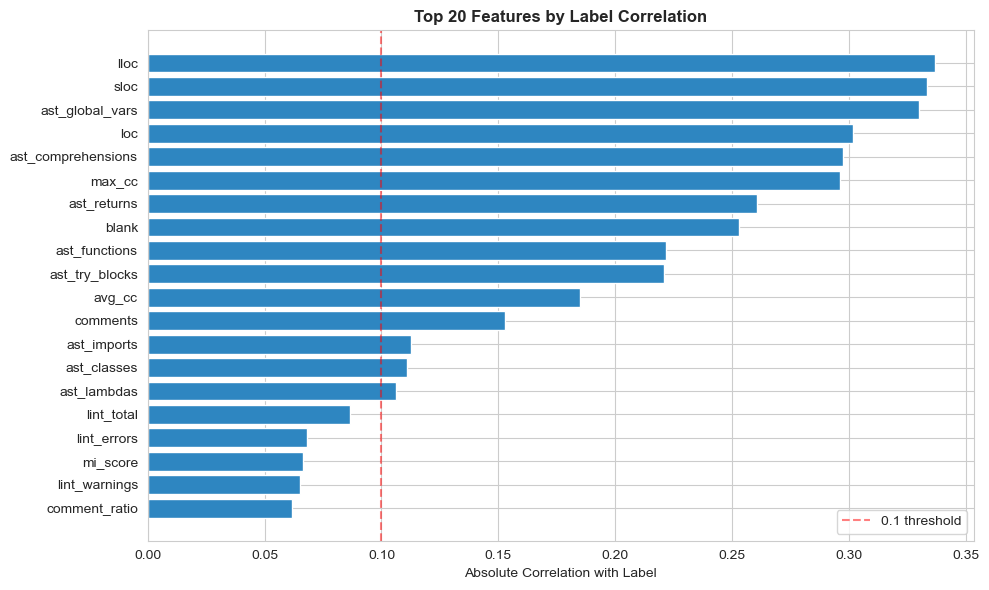

In [36]:
# Bar chart — top 20 features by label correlation
top20 = correlations.head(20)

plt.figure(figsize=(10, 6))
colors_bar = ["#2E86C1" if not c.startswith("tfidf") else "#E67E22" for c in top20.index]
plt.barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1], edgecolor="white")
plt.xlabel("Absolute Correlation with Label")
plt.title("Top 20 Features by Label Correlation", fontweight="bold")
plt.axvline(0.1, color="red", linestyle="--", alpha=0.5, label="0.1 threshold")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# Full feature matrix (unscaled, with label)
features_out = X.copy()
features_out["quality_label"] = y_raw.values
features_out.to_csv(feature_csv, index=False)
print(f"✅ features.csv          → {feature_csv}  ({features_out.shape})")

# Train/test splits (scaled, as CSV)
pd.DataFrame(X_train_scaled, columns=X.columns).to_csv(x_train_csv, index=False)
pd.DataFrame(X_test_scaled,  columns=X.columns).to_csv(x_test_csv,  index=False)
pd.DataFrame({"y": y_train}).to_csv(y_train_csv, index=False)
pd.DataFrame({"y": y_test }).to_csv(y_test_csv,  index=False)

print(f"✅ X_train.csv           → {x_train_csv}  ({X_train_scaled.shape})")
print(f"✅ X_test.csv            → {x_test_csv}   ({X_test_scaled.shape})")
print(f"✅ y_train.csv           → {y_train_csv}  ({len(y_train)} samples)")
print(f"✅ y_test.csv            → {y_test_csv}   ({len(y_test)} samples)")
print(f"✅ scaler.json           → {scaler_path}")
print(f"✅ label_encoder.json    → {encoder_path}")
print(f"✅ tfidf_vocabulary.json → {tfidf_vocab}")

✅ features.csv          → C:\Users\LOQ\Documents\code_quality_machine\output\features_dataset.csv  ((1006, 227))
✅ X_train.csv           → C:\Users\LOQ\Documents\code_quality_machine\output\x_train.csv  ((804, 226))
✅ X_test.csv            → C:\Users\LOQ\Documents\code_quality_machine\output\x_test.csv   ((202, 226))
✅ y_train.csv           → C:\Users\LOQ\Documents\code_quality_machine\output\y_train.csv  (804 samples)
✅ y_test.csv            → C:\Users\LOQ\Documents\code_quality_machine\output\y_test.csv   (202 samples)
✅ scaler.json           → C:\Users\LOQ\Documents\code_quality_machine\output\scaler.json
✅ label_encoder.json    → C:\Users\LOQ\Documents\code_quality_machine\output\encoder.json
✅ tfidf_vocabulary.json → C:\Users\LOQ\Documents\code_quality_machine\output\tfidf_vocab.json


In [42]:
# ── Phase 2 Summary ────────────────────────────────────────────────────────
print("=" * 55)
print("Feature Engineering")
print("=" * 55)
print(f"  Total samples          : {len(X)}")
print(f"  Training samples       : {X_train_scaled.shape[0]}")
print(f"  Test samples           : {X_test_scaled.shape[0]}")
print(f"  Total features         : {X.shape[1]}")
print(f"    Phase 1 metrics      : {len(p1_cols)}")
print(f"    AST features         : {ast_df.shape[1]}")
print(f"    Lint signals         : {lint_df.shape[1]}")
print(f"    TF-IDF vectors       : {tfidf_df.shape[1]}")
print()
print("  Output files ready for Phase 3 (ML Modeling):")
print(f"    {x_train_csv}")
print(f"    {x_test_csv}")
print(f"    {y_train_csv}")
print(f"    {y_test_csv}")
print(f"    {scaler_path}")
print(f"    {encoder_path}")


Feature Engineering
  Total samples          : 1006
  Training samples       : 804
  Test samples           : 202
  Total features         : 226
    Phase 1 metrics      : 9
    AST features         : 13
    Lint signals         : 4
    TF-IDF vectors       : 200

  Output files ready for Phase 3 (ML Modeling):
    C:\Users\LOQ\Documents\code_quality_machine\output\x_train.csv
    C:\Users\LOQ\Documents\code_quality_machine\output\x_test.csv
    C:\Users\LOQ\Documents\code_quality_machine\output\y_train.csv
    C:\Users\LOQ\Documents\code_quality_machine\output\y_test.csv
    C:\Users\LOQ\Documents\code_quality_machine\output\scaler.json
    C:\Users\LOQ\Documents\code_quality_machine\output\encoder.json
